# Building Smart Image Classification Models
Imagine you’re part of a team at a tech company working on cool projects like automatic image recognition. Your job is to build a smart image classifier using one of the two provided datasets:

1. CIFAR-10 Reduced: A dataset of RGB images representing everyday objects across 10 categories, such as airplanes, cars, and animals. https://www.tensorflow.org/datasets/catalog/cifar10

Your goal is to explore the dataset, build a model using pre-trained deep learning techniques, and make it as accurate as possible. You’ll need to think about how to handle the challenges the dataset might throw at you and document your process along the way.

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [2]:
# Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [3]:
# Select Classes to Include (e.g., airplane, automobile, bird, cat, dog)
selected_classes = [0, 1, 2, 3, 5]  # Class indices for airplane, automobile, bird, cat, dog

# Filter the Dataset to Include Only Selected Classes
train_filter = np.isin(y_train, selected_classes).flatten()
test_filter = np.isin(y_test, selected_classes).flatten()

x_train_subset = x_train[train_filter]
y_train_subset = y_train[train_filter]
x_test_subset = x_test[test_filter]
y_test_subset = y_test[test_filter]

# Save Subset to Disk
np.savez("cifar10_reduced_classes.npz",
         train_images=x_train_subset, train_labels=y_train_subset,
         test_images=x_test_subset, test_labels=y_test_subset)

print("CIFAR-10 reduced classes dataset saved as cifar10_reduced_classes.npz")

CIFAR-10 reduced classes dataset saved as cifar10_reduced_classes.npz


#Loading reduced dataset

In this notebook we will use a reduced CIFAR-10 dataset which is saved as `cifar10_reduced_classes.npz`, containing only:
- airplane (0)
- automobile (1)
- bird (2)
- cat (3)
- dog (5)

first load the dataset and confirm the label and shape values.

# First we will load the dataset NPZ and do some basic checks

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

data = np.load("cifar10_reduced_classes.npz")
x_train_subset = data["train_images"]
y_train_subset = data["train_labels"].flatten()
x_test_subset  = data["test_images"]
y_test_subset  = data["test_labels"].flatten()

print("Train images:", x_train_subset.shape)
print("Train labels:", y_train_subset.shape)
print("Test images:", x_test_subset.shape)
print("Test labels:", y_test_subset.shape)

print("Unique labels in subset:", np.unique(y_train_subset))


Train images: (25000, 32, 32, 3)
Train labels: (25000,)
Test images: (5000, 32, 32, 3)
Test labels: (5000,)
Unique labels in subset: [0 1 2 3 5]


## Dataset Exploration

We explore:
- image size and channels
- class distribution (images per class)
- sample images per class

This stage helps us understand dataset balance and visual difficulty (e.g., cat vs dog confusion).


Now we will give names to our classes to specify th labels not just numbers

In [5]:
# CIFAR-10 full labels
cifar10_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

selected_classes = [0, 1, 2, 3, 5]
selected_names = [cifar10_names[i] for i in selected_classes]
selected_names


['airplane', 'automobile', 'bird', 'cat', 'dog']

Train class counts: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'dog': 5000}
Test class counts: {'airplane': 1000, 'automobile': 1000, 'bird': 1000, 'cat': 1000, 'dog': 1000}


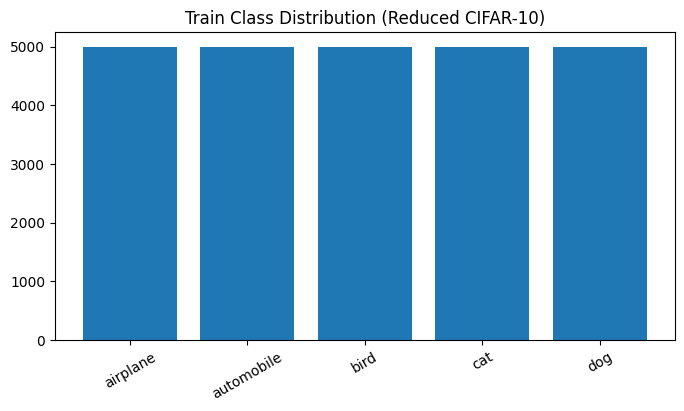

In [6]:
# Distribution counts
train_counts = {cifar10_names[c]: int(np.sum(y_train_subset == c)) for c in selected_classes}
test_counts  = {cifar10_names[c]: int(np.sum(y_test_subset == c)) for c in selected_classes}

print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

plt.figure(figsize=(8,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Train Class Distribution (Reduced CIFAR-10)")
plt.xticks(rotation=30)
plt.show()


# Visualising some samples from our data

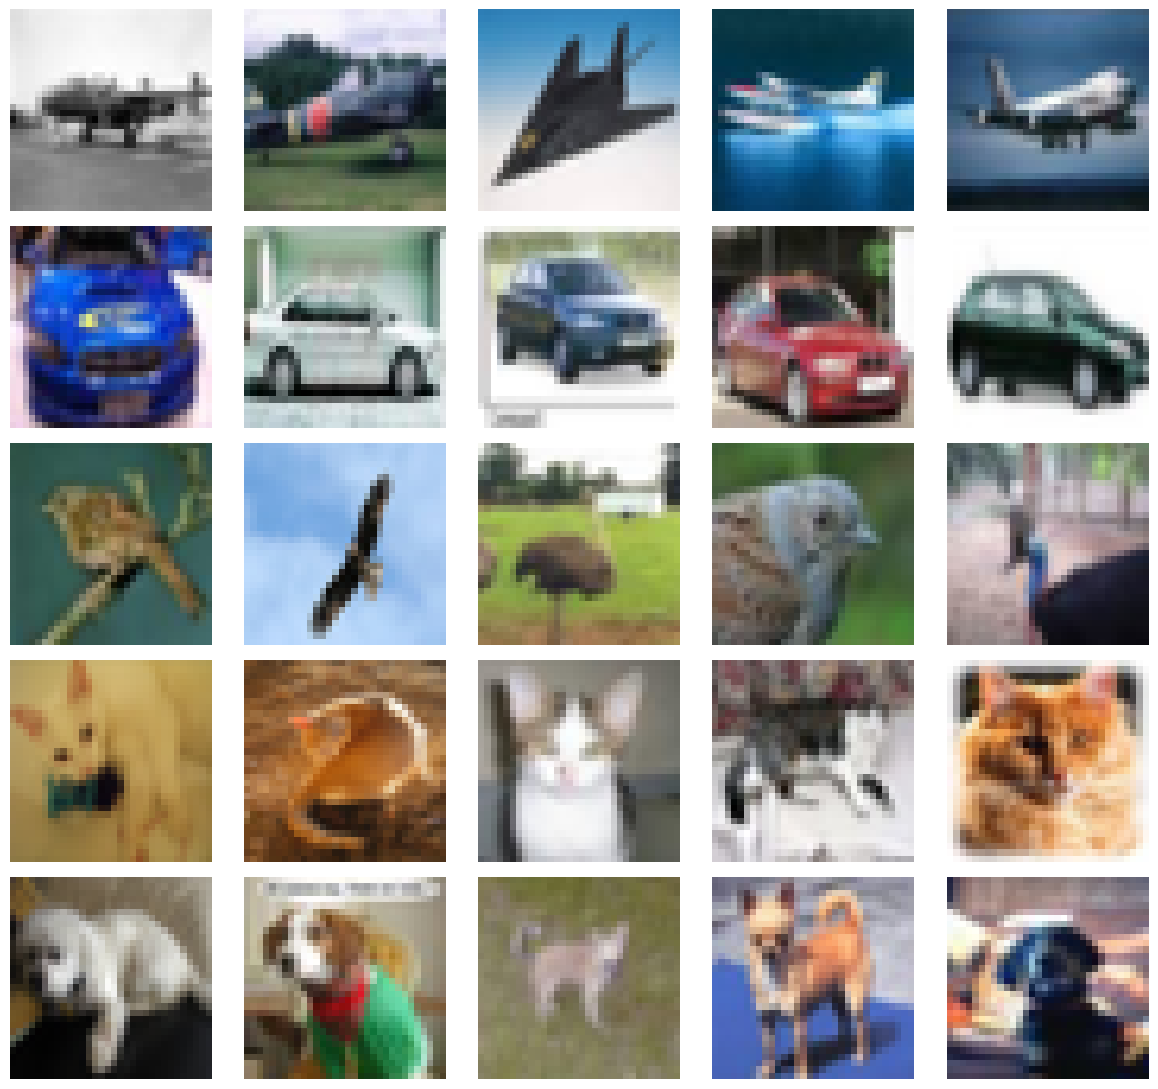

In [7]:
def show_samples(x, y, class_ids, class_names, n=5):
    plt.figure(figsize=(12, 2.2*len(class_ids)))
    plot_idx = 1
    for cid in class_ids:
        idxs = np.where(y == cid)[0]
        chosen = np.random.choice(idxs, size=n, replace=False)
        for j, i in enumerate(chosen):
            plt.subplot(len(class_ids), n, plot_idx)
            plt.imshow(x[i])
            plt.axis("off")
            if j == 0:
                plt.ylabel(class_names[cid], fontsize=12)
            plot_idx += 1
    plt.tight_layout()
    plt.show()

class_names_map = {i: cifar10_names[i] for i in range(10)}
show_samples(x_train_subset, y_train_subset, selected_classes, class_names_map, n=5)


# Train and validation data splitting and  Label remapping

Our selected classes are originally: {0, 1, 2, 3, 5}.  
We remap them to: {0, 1, 2, 3, 4} for training consistency.

We also create a validation split from the training subset to monitor overfitting.


In [8]:
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_subset, y_train_subset,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_subset
)

label_to_index = {lab:i for i, lab in enumerate(selected_classes)}     # {0:0, 1:1, 2:2, 3:3, 5:4}
index_to_label = {i:lab for lab,i in label_to_index.items()}           # reverse mapping

def remap_labels(y):
    return np.array([label_to_index[int(v)] for v in y], dtype=np.int32)

y_tr_mapped  = remap_labels(y_tr)
y_val_mapped = remap_labels(y_val)
y_test_mapped = remap_labels(y_test_subset)

print("Train split:", x_tr.shape, y_tr_mapped.shape)
print("Val split:", x_val.shape, y_val_mapped.shape)
print("Test:", x_test_subset.shape, y_test_mapped.shape)


Train split: (20000, 32, 32, 3) (20000,)
Val split: (5000, 32, 32, 3) (5000,)
Test: (5000, 32, 32, 3) (5000,)


## Preprocessing and Data Augmentation

### Why resizing the images ?
EfficientNetB0 expects larger inputs (commonly 224×224). CIFAR-10 images are 32×32, so we resize them.

### Why data augmentation?
Augmentation helps reduce overfitting by exposing the model to slightly altered versions of images (flips, rotations, zoom), improving generalisation.

### Why EfficientNet preprocessing?
Pre-trained models expect input preprocessing consistent with their ImageNet training.


In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = len(selected_classes)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

preprocess = tf.keras.applications.efficientnet.preprocess_input

def make_ds(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.map(lambda im, lab: (tf.image.resize(im, IMG_SIZE), lab), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda im, lab: (tf.cast(im, tf.float32), lab), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda im, lab: (data_augmentation(im, training=True), lab), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda im, lab: (preprocess(im), lab), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(x_tr, y_tr_mapped, training=True)
val_ds   = make_ds(x_val, y_val_mapped, training=False)
test_ds  = make_ds(x_test_subset, y_test_mapped, training=False)

train_ds, val_ds


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>)

## Transfer Learning with EfficientNetB0 (ImageNet)

### Model choice justification
EfficientNetB0 is a CNN trained on ImageNet that balances accuracy and computational efficiency.  
It is suitable for a one-day hackathon because it:
- provides strong feature extraction
- trains quickly in Colab
- often performs well on smaller datasets after fine-tuning

### Strategy
1. Load EfficientNetB0 without its original classifier (`include_top=False`)
2. Freeze the base model initially (train only new head layers)
3. Add a custom classifier head for 5 classes
4. Fine-tune the top layers of the base model for improved performance


In [10]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False  # freeze for baseline training

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Training Setup and Overfitting Control

To improve training stability and avoid overfitting, we use:
- EarlyStopping: stops training when validation performance stops improving
- ReduceLROnPlateau: lowers learning rate if validation loss plateaus
- ModelCheckpoint: saves the best model weights automatically


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint("best_model_stage1.keras", monitor="val_accuracy", save_best_only=True)
]


In [12]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 258ms/step - accuracy: 0.8028 - loss: 0.5111 - val_accuracy: 0.9152 - val_loss: 0.2291 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.8870 - loss: 0.2933 - val_accuracy: 0.9240 - val_loss: 0.2085 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8961 - loss: 0.2708 - val_accuracy: 0.9236 - val_loss: 0.2028 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9035 - loss: 0.2472 - val_accuracy: 0.9218 - val_loss: 0.2076 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9076 - loss: 0.2410 - val_accuracy: 0.9326 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9159 - loss: 0.2125 - val_accuracy: 0.9266 - val_loss: 0.2012 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.

# Plot Training Curves

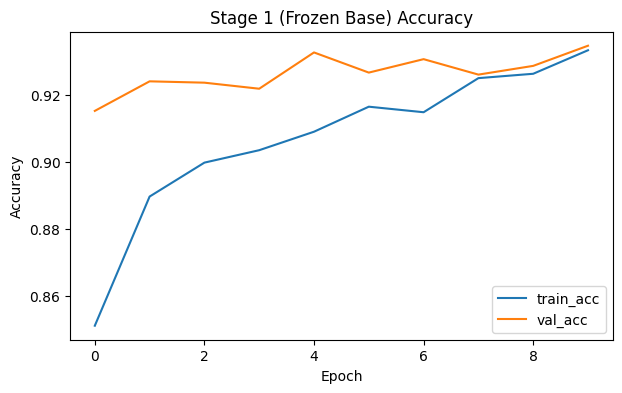

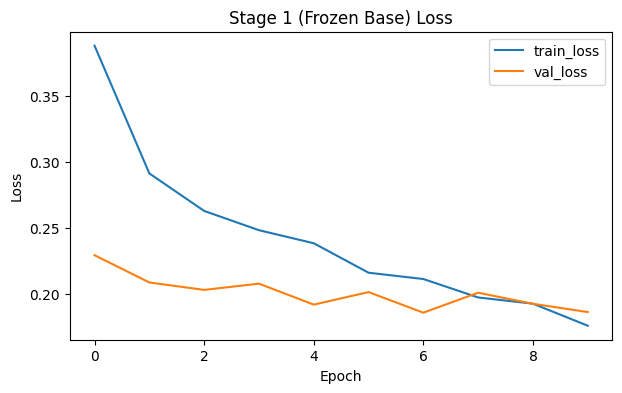

In [13]:
def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(7,4))
    plt.plot(hist.history["accuracy"], label="train_acc")
    plt.plot(hist.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist.history["loss"], label="train_loss")
    plt.plot(hist.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history1, "Stage 1 (Frozen Base)")


# Fine-Tuning

## Fine-Tuning Stage (Improving Performance)

After training the custom head, we fine-tune the top layers of EfficientNetB0.

Why?
- The model now learns dataset-specific patterns for our selected classes
- Fine-tuning often improves accuracy and class-level metrics

We unfreeze the last blocks of the base model and train with a lower learning rate to avoid destroying useful pre-trained features.


# Train Stage 2

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 220ms/step - accuracy: 0.8929 - loss: 0.3026 - val_accuracy: 0.9406 - val_loss: 0.1703 - learning_rate: 1.0000e-04
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.9299 - loss: 0.1872 - val_accuracy: 0.9446 - val_loss: 0.1562 - learning_rate: 1.0000e-04
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.9427 - loss: 0.1528 - val_accuracy: 0.9490 - val_loss: 0.1483 - learning_rate: 1.0000e-04
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.9552 - loss: 0.1253 - val_accuracy: 0.9496 - val_loss: 0.1462 - learning_rate: 1.0000e-04
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.9594 - loss: 0.1126 - val_accuracy: 0.9528 - val_loss: 0.1440 - learning_rate: 1.0000e-04
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.9645 - loss: 0.0946 - val_accuracy: 0.9516 - val_loss: 0.1480 - learning_rate: 1.0000e-04
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 1

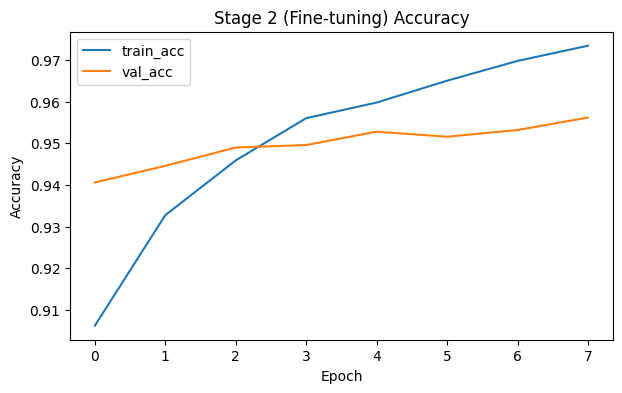

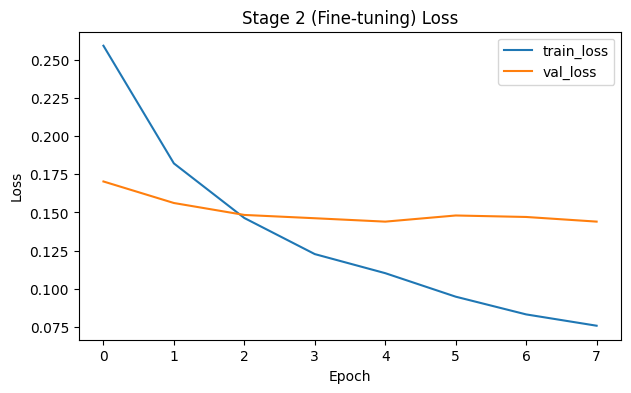

In [15]:
base_model.trainable = True

# Fine-tune only top layers (keep most layers frozen)
fine_tune_at = int(len(base_model.layers) * 0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint("best_model_stage2.keras", monitor="val_accuracy", save_best_only=True)
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_ft
)

plot_history(history2, "Stage 2 (Fine-tuning)")


# Evaluation on Test Set

## Model Evaluation (Test Set)

We evaluate performance using:
- Accuracy
- Precision, Recall, F1-score (classification report)
- Confusion matrix (class-level error analysis)

This provides a more detailed view than accuracy alone and supports critical evaluation of model strengths and weaknesses.


# Predictions + Classification Report

In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

# Predict labels
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels in same order as test_ds
y_true = y_test_mapped

# Classification report
target_names = [cifar10_names[index_to_label[i]] for i in range(NUM_CLASSES)]
print("Target names:", target_names)

print(classification_report(y_true, y_pred, target_names=target_names))


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9505 - loss: 0.1351
Test accuracy: 0.9539999961853027
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 144ms/step
Target names: ['airplane', 'automobile', 'bird', 'cat', 'dog']
              precision    recall  f1-score   support

    airplane       0.97      0.99      0.98      1000
  automobile       0.99      0.99      0.99      1000
        bird       0.98      0.94      0.96      1000
         cat       0.90      0.92      0.91      1000
         dog       0.92      0.93      0.93      1000

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



# Confusion Matrix Plot

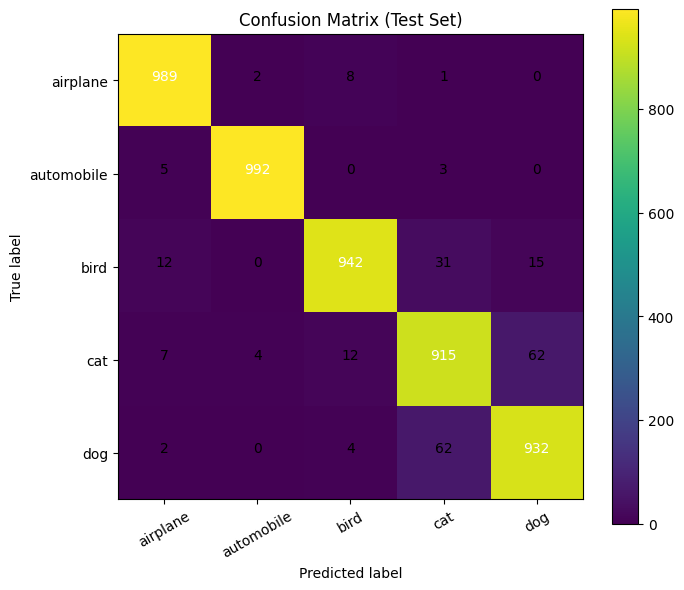

In [18]:
def plot_confusion_matrix(cm, classes, title="Confusion matrix"):
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=30)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

import itertools
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, target_names, title="Confusion Matrix (Test Set)")


## Random Sample Predictions (Model in Action)

To further demonstrate model behaviour, we randomly select test images and display the true and predicted labels. This provides an intuitive understanding of model performance and highlights both correct and incorrect predictions in real examples.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


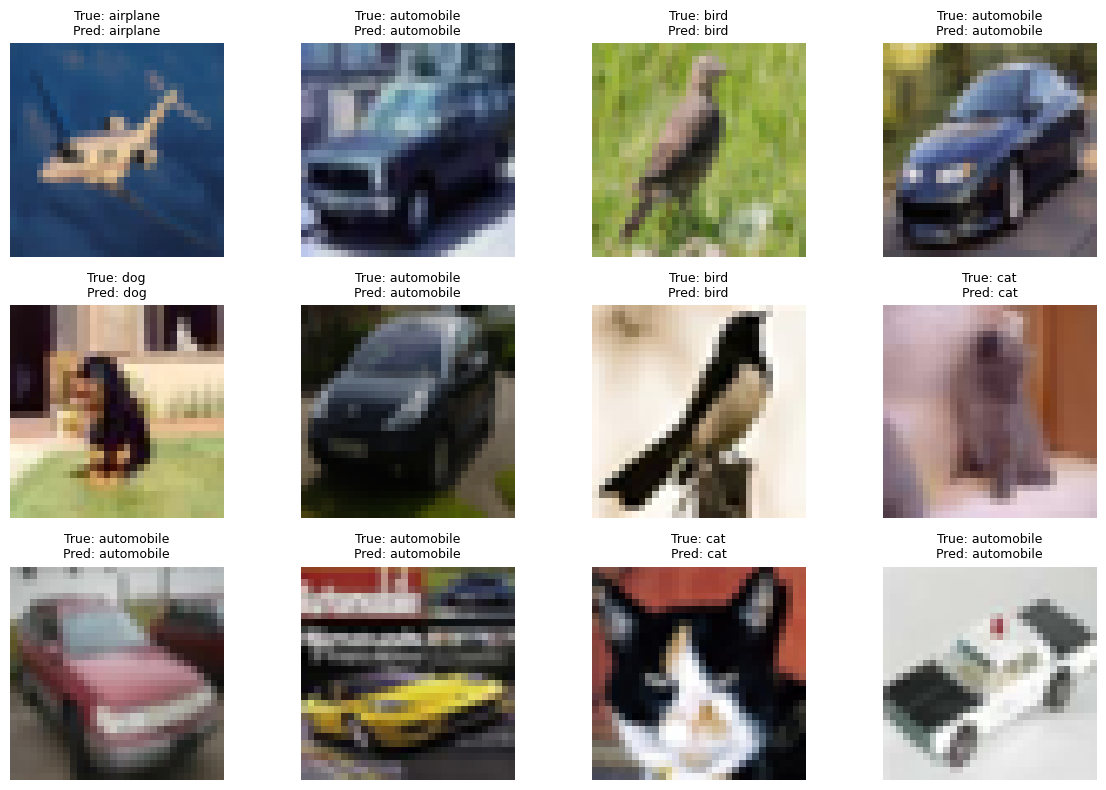

In [22]:
# Random predictions on test samples
num_samples = 12
rand_indices = np.random.choice(len(x_test_subset), size=num_samples, replace=False)

plt.figure(figsize=(12,8))
for i, idx in enumerate(rand_indices):
    plt.subplot(3,4,i+1)
    img = x_test_subset[idx]

    # Prediction
    pred_class, probs = predict_single_image(img)
    true_class = cifar10_names[y_test_subset[idx]]

    plt.imshow(img)
    plt.title(f"True: {true_class}\nPred: {pred_class}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Visual Analysis of Misclassified Images

To better understand model limitations, we visualise a small number of misclassified test images. This helps identify whether errors are caused by visually similar classes, ambiguous images, or low-resolution details.


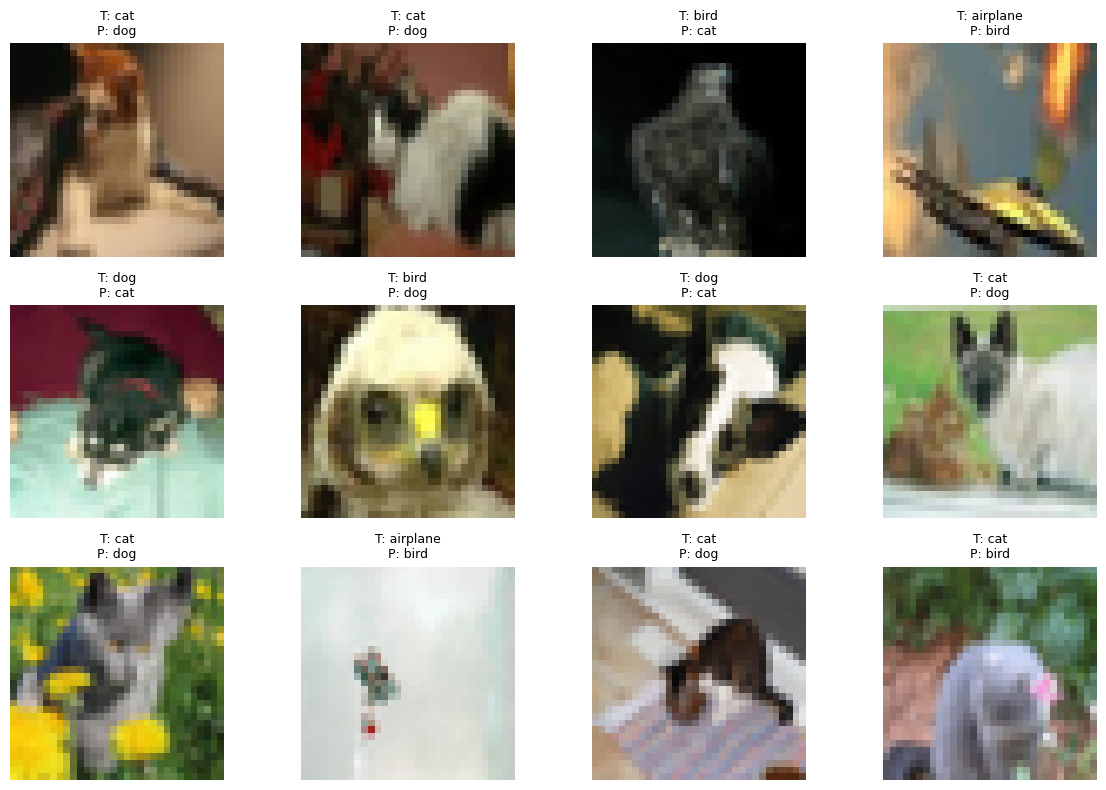

In [21]:
# Visualise some misclassified images
mis_idx = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12,8))
for i, idx in enumerate(mis_idx[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test_subset[idx])
    true_label = target_names[y_true[idx]]
    pred_label = target_names[y_pred[idx]]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Save Model + Inference Function

## Saving the Model and Predicting New Images

We save the trained model for reproducibility and deployment.  
We also define a prediction function that accepts a new image and returns the predicted class.


In [19]:
model.save("final_efficientnet_cifar10_reduced.keras")
print("Saved as final_efficientnet_cifar10_reduced.keras")

def predict_single_image(img_array):
    """
    img_array: numpy array of shape (H, W, 3) in RGB format (0-255)
    Returns: predicted class name and probabilities
    """
    img = tf.image.resize(img_array, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)
    img = preprocess(img)

    probs = model.predict(img)[0]
    pred_idx = np.argmax(probs)
    pred_class = cifar10_names[index_to_label[pred_idx]]
    return pred_class, probs

# Example usage on a test image:
example_img = x_test_subset[0]
pred_class, probs = predict_single_image(example_img)
print("Predicted:", pred_class)
print("Probabilities:", probs)


Saved as final_efficientnet_cifar10_reduced.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted: cat
Probabilities: [2.2995524e-08 9.5912696e-08 5.5345112e-07 9.9811798e-01 1.8812943e-03]


For the final evaluation, we tested the model on completely unseen data to check how well it generalises. The model achieved a test accuracy of 95.4% and a macro F1-score of 0.95, which indicates strong and balanced performance across all five classes. for the stage 1 we got the accuracy of 95 percent and for the stage 2 after fine tunning changing a little bit of hyper parameters we got our accuracy improved to 97%.The model performs very well overall, and most mistakes are due to visual similarity between classes rather than a problem with the model itself.the evaluation confirms that transfer learning aand fine tunning are effective, while also highlighting realistic limitations of low-resolution image data.